In [1]:
import pandas as pd
from pathlib import Path
import pyarrow.parquet as pq
from dataclasses import dataclass
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib
import pickle
import scipy.stats as scist
import umap


from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, make_scorer
from sklearn.model_selection import GridSearchCV

# Extracting and Preparing Data

In [2]:
dataset_root = Path(r"./dataset") # Raw string works without escaping \


@dataclass
class Case():
    info: pd.DataFrame
    measurements: pd.DataFrame


class RawDataset():

    def __init__(self, root, unit = "VG4", load_training=False, load_synthetic=False) -> None:
        
        
        read_pq_file = lambda f: pq.read_table(root / f).to_pandas()
        
        
        cases = {
            "test": [f"{unit}_generator_data_testing_real_measurements.parquet", root / f"{unit}_generator_data_testing_real_info.csv" ], 
        }
        
        if load_training:
            cases = {
                **cases,
                "train": [f"{unit}_generator_data_training_measurements.parquet", root / f"{unit}_generator_data_training_info.csv" ], 
            }
        
        if load_synthetic:
            cases = {
                **cases,
                "test_s01": [f"{unit}_generator_data_testing_synthetic_01_measurements.parquet", root / f"{unit}_generator_data_testing_synthetic_01_info.csv"], 
                "test_s02": [f"{unit}_generator_data_testing_synthetic_02_measurements.parquet", root / f"{unit}_generator_data_testing_synthetic_02_info.csv"]
            }
        
        
        self.data_dict = dict()
        
        for id_c, c in cases.items():
            # if you need to verify the parquet header:
            # pq_rows = RawDataset.read_parquet_schema_df(root / c[0])
            info = pd.read_csv(c[1])
            measurements = read_pq_file(c[0])
            self.data_dict[id_c] = Case(info, measurements)
            
        
        
    @staticmethod
    def read_parquet_schema_df(uri: str) -> pd.DataFrame:
        """Return a Pandas dataframe corresponding to the schema of a local URI of a parquet file.

        The returned dataframe has the columns: column, pa_dtype
        """
        # Ref: https://stackoverflow.com/a/64288036/
        schema = pq.read_schema(uri, memory_map=True)
        schema = pd.DataFrame(({"column": name, "pa_dtype": str(pa_dtype)} for name, pa_dtype in zip(schema.names, schema.types)))
        schema = schema.reindex(columns=["column", "pa_dtype"], fill_value=pd.NA)  # Ensures columns in case the parquet file has an empty dataframe.
        return schema

## Splitting the dataset

In [3]:
# Define Operating Modes
Operating_modes_name = [
    "turbine_mode", "equilibrium_turbine_mode", "pump_mode", "equilibrium_pump_mode",
    "short_circuit_mode", "equilibrium_short_circuit_mode", "machine_on", "machine_off", 
    "dyn_only_on", "all"
]

# Time Series Extraction Functions
def extracting_name_groups_time_series(rds, set_type):
    df_name_control_sensors = rds.data_dict[set_type].info
    control_time_series_name = df_name_control_sensors[
        (df_name_control_sensors['control_signal'] == True) &
        (df_name_control_sensors["signal_type"] == "Measurement")
    ]
    sensors_time_series_name = df_name_control_sensors[
        (df_name_control_sensors['control_signal'] == False) &
        (df_name_control_sensors["signal_type"] == "Measurement")
    ]
    return control_time_series_name["attribute_name"], sensors_time_series_name["attribute_name"]

def extracting_groups_time_series(rds, set_type):
    control_time_series_name, sensors_time_series_name = extracting_name_groups_time_series(rds, set_type=set_type)
    control_df = rds.data_dict[set_type].measurements[control_time_series_name]
    sensors_df = rds.data_dict[set_type].measurements[sensors_time_series_name]
    operating_modes_df = rds.data_dict[set_type].measurements[Operating_modes_name]
    return control_df, sensors_df, operating_modes_df

def get_indexes_operating_mode(operating_modes_df, operating_conditions):
    mask = pd.Series([True] * len(operating_modes_df), index=operating_modes_df.index)
    for column, value in operating_conditions.items():
        mask &= (operating_modes_df[column] == value)
    return operating_modes_df[mask].index

# Helper functions for feature extraction 
def feature_extraction(df, feature_prefixes, new_feature_name):
    feature_columns = df.columns[df.columns.str.startswith(tuple(feature_prefixes))]
    df[new_feature_name] = df[feature_columns].sum(axis=1)
    df.drop(columns=feature_columns, inplace=True)
    return df

# Helper functions for normalization
def normalize_features(df,scaler, fit = True):
    numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
    df[numerical_columns] = scaler.fit_transform(df[numerical_columns]) if fit else scaler.transform(df[numerical_columns])
    return df

def dynamic_group_features(df):
    feature_groups = {
        'voltage_current': df.columns[df.columns.str.startswith(("exc", "ph", "elec", "mid", "neutral"))].tolist(),
        'stator_temperature': df.columns[df.columns.str.startswith("stat_") & 
                                         df.columns.str.contains("coil|magn")].tolist(),
        'cooling_system': df.columns[df.columns.str.startswith("air_circ_")].tolist(),
        'heat_exchanger': df.columns[df.columns.str.startswith("water_circ_")].tolist()
    }

    # Flatten the list of all grouped features
    grouped_features = [feature for group in feature_groups.values() for feature in group]
    # Find complementary features
    complementary_features = [col for col in df.columns if col not in grouped_features]
    
    feature_groups['complementary'] = complementary_features

    return feature_groups

def preprocess_hydraulic_data(rds, set_type, operating_conditions, scaler, fit):
    """
    Preprocess the hydraulic site data to return normalized control and sensor signals filtered by operating conditions.

    Parameters:
    - rds: RawDataset object containing the data dictionary
    - set_type: Type of dataset to use ('train', 'test', etc.)
    - feature_group: The group of sensor features to select for preprocessing
    - operating_conditions: A dictionary specifying operating conditions to filter the data
    
    Returns:
    - Dictionary with two normalized and filtered DataFrames: control signals and sensor signals
    """
    # Step 1: Extract control, sensor, and operating mode time series
    control_df, sensors_df, operating_modes_df = extracting_groups_time_series(rds, set_type=set_type)

    # Step 2: Filter based on operating conditions if specified
    if operating_conditions:
        indexes = get_indexes_operating_mode(operating_modes_df, operating_conditions)
        control_df = control_df.loc[indexes]
        sensors_df = sensors_df.loc[indexes]
        
    # Select features containing both 'water' and 'opening' in their name
    water_opening_features = [col for col in control_df.columns if "water" in col and "opening" in col]
    control_df = feature_extraction(control_df, water_opening_features, "water_opening_sum")

    # Select features containing both 'injector' and 'opening' in their name
    injector_opening_features = [col for col in control_df.columns if "injector" in col and "opening" in col]
    control_df = feature_extraction(control_df, injector_opening_features, "injector_opening_sum")

    # Step 4 : Extract the groups of interest
    grouped_data = dynamic_group_features(sensors_df)
    selected_sensor_data = []
    for key in grouped_data.keys():
        selected_sensor_data.append(sensors_df[grouped_data[key]])

    sensors_df = pd.concat([selected_sensor_data[i] for i in range(5)], axis=1)

    # Step 5 : Concatenate the df into one
    df_signals = pd.concat([control_df, sensors_df], axis=1)

    # Step 6: Normalize the signals DataFrame
    #df_signals = normalize_features(df_signals, scaler=scaler, fit=fit)

    # Step 7 : Drop pump_calculated_flow for turbine mode 
    df_signals.drop(columns="pump_calculated_flow", inplace=True)    

    return df_signals

# Loading Train Dataset and Preparing for training

In [4]:
rds_u5_train = RawDataset(dataset_root, "VG5", load_synthetic=False, load_training=True)

In [5]:
# Turbine Steady State Operation
operating_conditions_set = {
    "dyn_only_on": False, "turbine_mode": True, "equilibrium_turbine_mode": True, "short_circuit_mode": False
}

scaler=StandardScaler()

# Preprocess data to get normalized control and sensor signals based on conditions
rds_u5_turb_ss_volt = preprocess_hydraulic_data(
    rds_u5_train, set_type="train", operating_conditions=operating_conditions_set,
    scaler=scaler, fit = True
)

del rds_u5_train # To free memory

In [6]:
training_df = rds_u5_turb_ss_volt

del rds_u5_turb_ss_volt

In [7]:
training_df.shape

(332235, 83)

#### Plotting to see the data

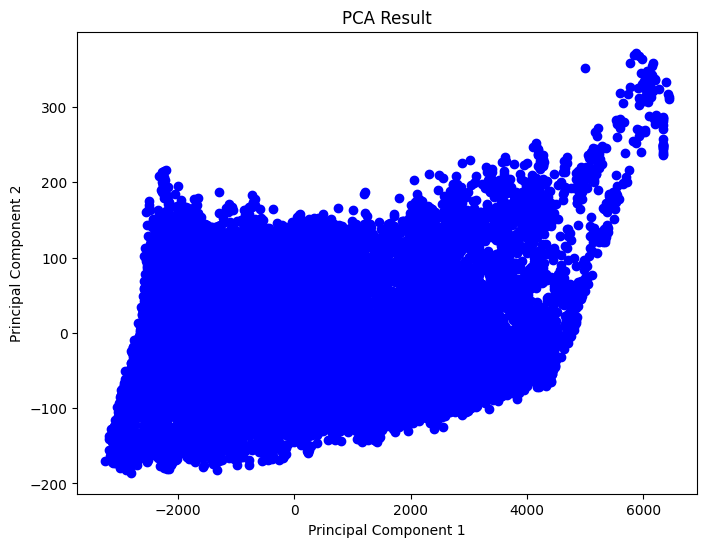

In [8]:
# Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(training_df[::10])

# Plot PCA result
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c='blue', marker='o')
plt.title('PCA Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

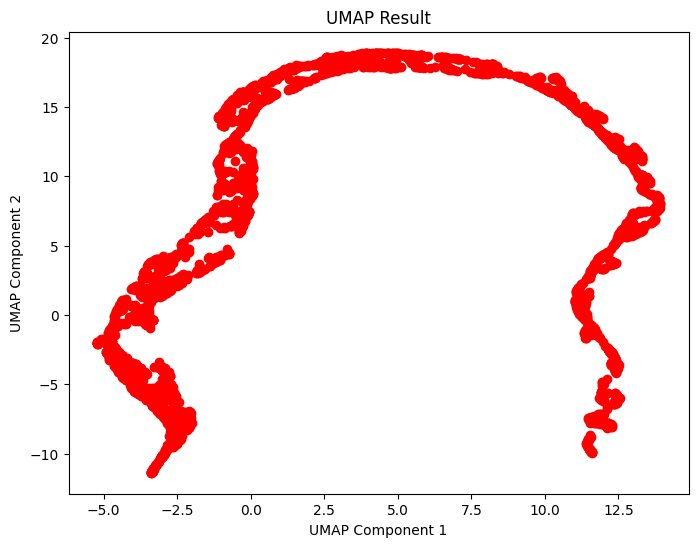

In [9]:
# Apply UMAP
umap_model = umap.UMAP(n_components=2)
umap_result = umap_model.fit_transform(training_df[::100])

# Plot UMAP result
plt.figure(figsize=(8, 6))
plt.scatter(umap_result[:, 0], umap_result[:, 1], c='red', marker='o')
plt.title('UMAP Result')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()

In [10]:
# In case it it useful
# train_data, val_data = train_test_split(training_df[::10], test_size=0.2, random_state=42)

# Computing statistical moments

In [11]:
def create_blocks(df, time_window):
    """
    Splits a DataFrame into blocks of size time_window along the first axis.

    Parameters:
    df (pd.DataFrame): The input DataFrame of shape (n_samples, n_features).
    time_window (int): The size of the block along the first axis.

    Returns:
    list of pd.DataFrame: A list of DataFrames, each of size (time_window, n_features).
    """
    n_samples = df.shape[0]
    blocks = [df.iloc[i:i + time_window] for i in range(0, n_samples, time_window)]
    return blocks

def compute_statistics(df):
    """
    Compute mean, variance, skewness, and kurtosis for each column of the DataFrame.

    Parameters:
    df (pd.DataFrame): The input DataFrame.

    Returns:
    pd.DataFrame: A DataFrame with statistics (mean, variance, skewness, kurtosis) as rows
                  and the columns being the indices of the means of the input DataFrame.
    """
    # Compute statistics
    mean = np.mean(df, axis=0)
    variance = scist.moment(df, moment=2, axis=0)
    skewness = scist.skew(df, axis=0)
    kurtosis = scist.kurtosis(df, axis=0)
    
    # Create DataFrame
    stats_df = pd.DataFrame({
        'mean': mean,
        'variance': variance,
        'skewness': skewness,
        'kurtosis': kurtosis
    }, index=mean.index).T
    
    return stats_df

def create_blocks_statistics(df, time_window):

    blocks = create_blocks(df=df, time_window=time_window)

    blocks_stats_moments = []

    for i in range(len(blocks)):
        blocks_stats_moments.append(compute_statistics(blocks[i]))

    return blocks_stats_moments



In [12]:
window_size=100

block_stats_moments = create_blocks_statistics(training_df, time_window=window_size)

/tmp/ipykernel_41058/1110366690.py:29: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  variance = scist.moment(df, moment=2, axis=0)
/tmp/ipykernel_41058/1110366690.py:30: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skewness = scist.skew(df, axis=0)
/tmp/ipykernel_41058/1110366690.py:31: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurtosis = scist.kurtosis(df, axis=0)
/tmp/ipykernel_41058/1110366690.py:29: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  variance = scist.moment(df, moment

In [13]:
def get_statistic(block_df,moment,column):

    moment_list = []

    for i in range(len(block_df)):
        df = block_df[i]
        moment_list.append(df[column].loc[moment])

    return np.array(moment_list)

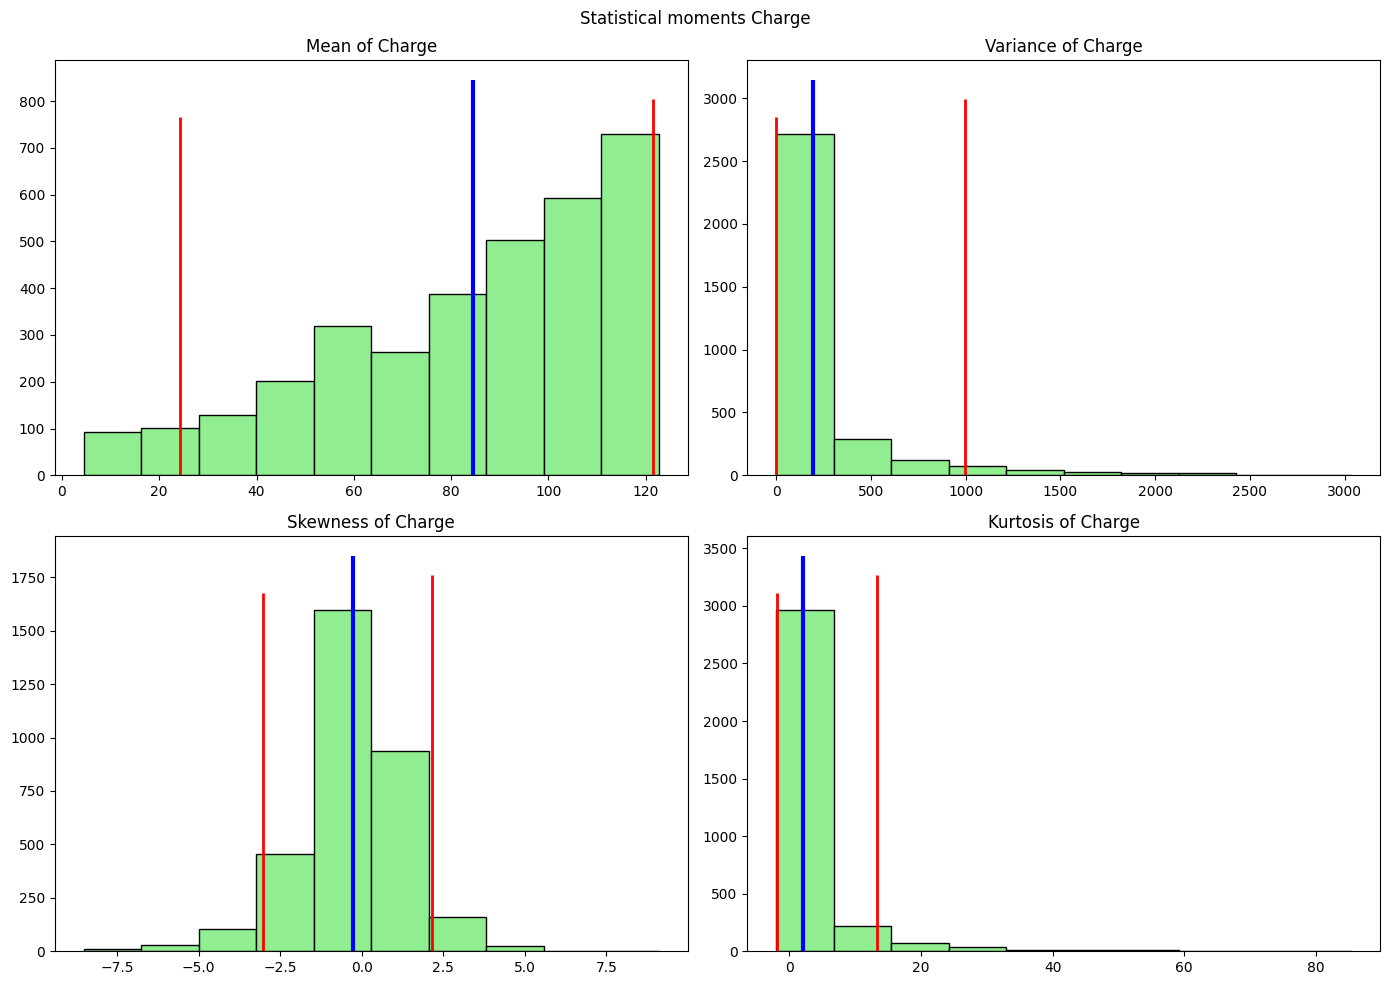

In [14]:
def plot_distribution(stat_values, title, ax):
    q_05 = np.quantile(stat_values, 0.05)
    q_95 = np.quantile(stat_values, 0.95)
    m = np.mean(stat_values)

    ax.hist(stat_values, bins=10, color='lightgreen', ec='black')
    ax.vlines(q_05, 0, ax.get_ylim()[1], color='red', linewidth=2)
    ax.vlines(q_95, 0, ax.get_ylim()[1], color='red', linewidth=2)
    ax.vlines(m, 0, ax.get_ylim()[1], color="blue", linewidth=3)
    ax.set_title(title)

# Extract statistics for the "charge" column
mean_charge = get_statistic(block_stats_moments, "mean", "charge")
variance_charge = get_statistic(block_stats_moments, "variance", "charge")
skewness_charge = get_statistic(block_stats_moments, "skewness", "charge")
kurtosis_charge = get_statistic(block_stats_moments, "kurtosis", "charge")

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Statistical moments Charge")

# Plot distributions
plot_distribution(mean_charge, 'Mean of Charge', axes[0, 0])
plot_distribution(variance_charge, 'Variance of Charge', axes[0, 1])
plot_distribution(skewness_charge, 'Skewness of Charge', axes[1, 0])
plot_distribution(kurtosis_charge, 'Kurtosis of Charge', axes[1, 1])

plt.tight_layout()
plt.show()

## Seeing the statistical moments in a PCA and UMAP

In [40]:
def flatten_block_stats_moments(block_stats_moments):
    flatten_stats_moments = []
    for i in range(len(block_stats_moments)):
        flatten_stats_moments.append(block_stats_moments[i].fillna(value=0).to_numpy().flatten())

    return np.array(flatten_stats_moments)

flatten_stats_moments = flatten_block_stats_moments(block_stats_moments)

In [41]:
scaler = MinMaxScaler()

flatten_stats_moments = scaler.fit_transform(flatten_stats_moments)

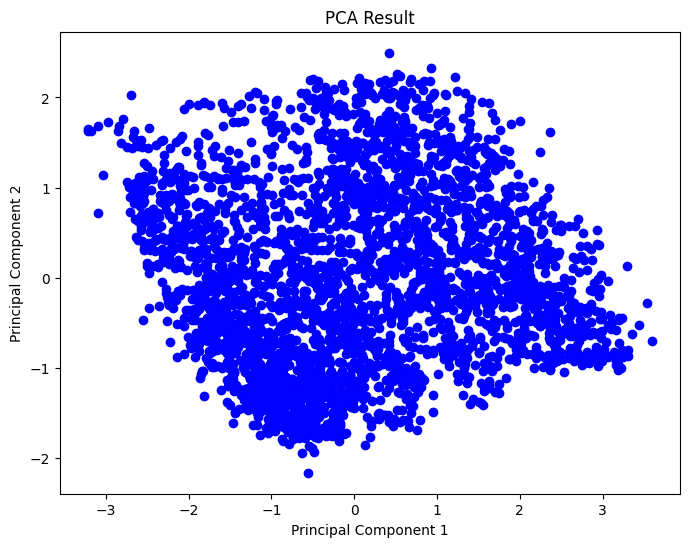

In [42]:
# Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(flatten_stats_moments)

# Plot PCA result
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c='blue', marker='o')
plt.title('PCA Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

## Testing on the synthetic dataset

In [43]:
# LOAD PARAMETERS
SYNTHETIC_PARAMS = {
    'unit': 'VG5',
    'test_set': '01',
    'anomaly_type': 'a',
    'set_type':'test_s01'
}

In [44]:
# Load only synthetic test data (no training data needed)
rds_u5_synth = RawDataset(dataset_root, "VG5", load_synthetic=True, load_training=False)

# Process synthetic datasets
rds_u5_synth_processed = preprocess_hydraulic_data(
    rds_u5_synth, set_type=SYNTHETIC_PARAMS['set_type'], operating_conditions=operating_conditions_set,  # set at the top
    scaler=scaler, fit=False
)

del rds_u5_synth

In [45]:
test_df =rds_u5_synth_processed

print(test_df.shape)

# Now you can safely delete if needed
del rds_u5_synth_processed

(45229, 83)


In [46]:
block_stats_moments_test = create_blocks_statistics(test_df, time_window=window_size)

/tmp/ipykernel_41058/1110366690.py:29: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  variance = scist.moment(df, moment=2, axis=0)
/tmp/ipykernel_41058/1110366690.py:30: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skewness = scist.skew(df, axis=0)
/tmp/ipykernel_41058/1110366690.py:31: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurtosis = scist.kurtosis(df, axis=0)
/tmp/ipykernel_41058/1110366690.py:29: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  variance = scist.moment(df, moment

In [47]:
flatten_stats_moments_test = flatten_block_stats_moments(block_stats_moments_test)

flatten_stats_moments_test = scaler.transform(flatten_stats_moments_test)

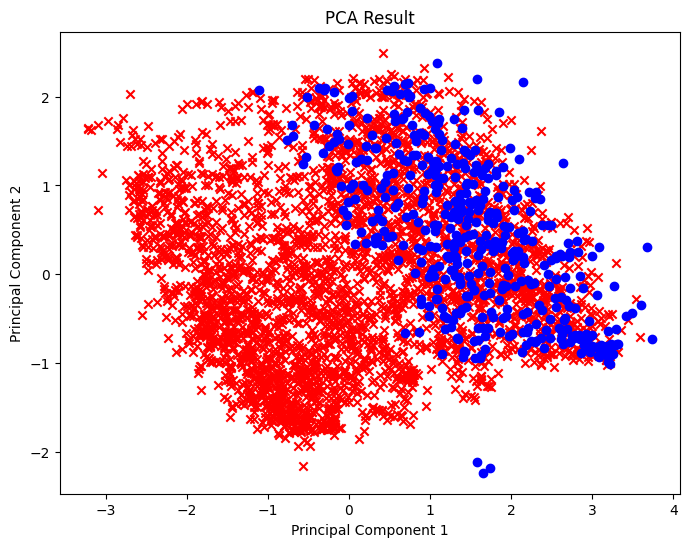

In [48]:
# Apply PCA
pca_result_test = pca.transform(flatten_stats_moments_test)

# Plot PCA result
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c='red', marker='x')
plt.scatter(pca_result_test[:, 0], pca_result_test[:, 1], c='blue', marker='o')
plt.title('PCA Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

### Adding labels

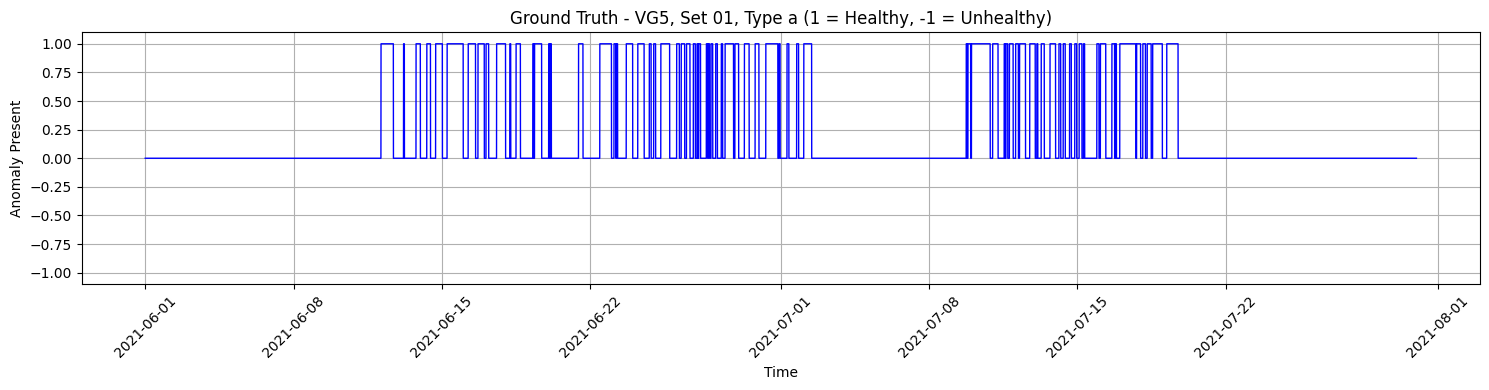

In [49]:
def obtain_ground_truth(dataset_root, unit="VG5", test_set="01", anomaly_type="a"):

    # Load anomaly data
    anomaly_file = Path(dataset_root) / "synthetic_anomalies" / f"{unit}_anomaly_{test_set}_type_{anomaly_type}.parquet"
    anomaly_data = pq.read_table(anomaly_file).to_pandas()
    ground_truth = anomaly_data["ground_truth"]
    #ground_truth = 1-anomaly_data['ground_truth'] # Setting healthy state to 1
    #ground_truth[ground_truth==0]=-1 # Setting anomaly to -1
    ground_truth_index = anomaly_data.index
    
    return ground_truth, ground_truth_index

def plot_ground_truth(ground_truth, ground_truth_index, unit, test_set, anomaly_type):
    """Plot ground truth data"""
    plt.figure(figsize=(15, 4))
    plt.plot(ground_truth_index, ground_truth, 'b-', linewidth=1)
    
    plt.title(f'Ground Truth - {unit}, Set {test_set}, Type {anomaly_type} (1 = Healthy, -1 = Unhealthy)')
    plt.ylim(-1.1, 1.1)
    plt.grid(True)
    plt.xlabel('Time')
    plt.ylabel('Anomaly Present')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

ground_truth, ground_truth_index = obtain_ground_truth(
    dataset_root,
    unit=SYNTHETIC_PARAMS['unit'],
    test_set=SYNTHETIC_PARAMS['test_set'],
    anomaly_type=SYNTHETIC_PARAMS['anomaly_type']
)

plot_ground_truth(
        ground_truth,
        ground_truth_index,
        unit=SYNTHETIC_PARAMS['unit'],
        test_set=SYNTHETIC_PARAMS['test_set'],
        anomaly_type=SYNTHETIC_PARAMS['anomaly_type']
    )

In [50]:
### Getting the normal labels
test_ground_truth = ground_truth.loc[test_df.index]

def create_label_blocks(df, time_window):
    n_samples = df.shape[0]

    blocks=[]

    for i in range(0, n_samples, time_window):
        block = df.iloc[i:i + time_window]
        
        numb_0 = (block==0).sum()

        if numb_0 > time_window/2:
            blocks.append(0)
        else :
            blocks.append(1)

    return np.array(blocks)


In [51]:
blocks_ground_truth = create_label_blocks(test_ground_truth, time_window=window_size)

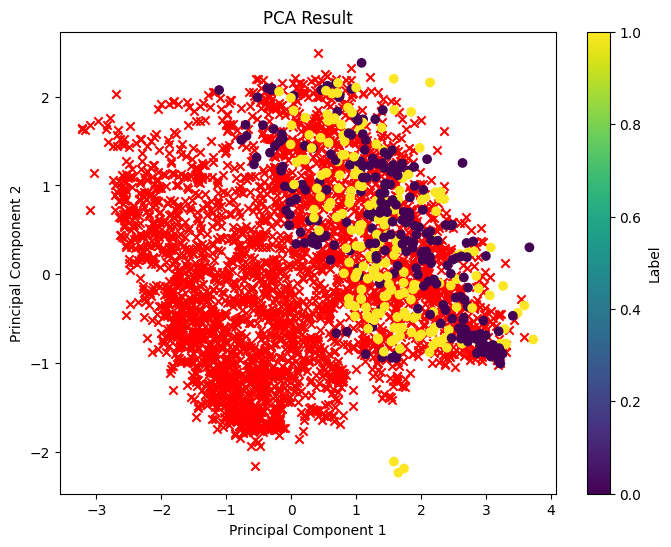

In [52]:
# Plot PCA result
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c='red', marker='x')
scatter = plt.scatter(pca_result_test[:, 0], pca_result_test[:, 1], c=blocks_ground_truth, cmap='viridis', marker='o')
plt.title('PCA Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Label')
plt.show()